Loaded dataset: 52 rows from 2001-10-01 00:00:00 to 2025-04-01 00:00:00
Available columns: ['DATE', 'GDP', 'CPI', 'Unemployment', 'FedFunds', 'Treasury10Y', 'Treasury2Y', 'YieldCurve']

PROCESSING LIQUIDITY INDICATORS
✓ Yield Curve scored
✓ Policy Rate scored

PROCESSING INFLATION INDICATORS
✓ CPI scored
✗ PMI data not found - using neutral score

PROCESSING GROWTH INDICATORS
✓ GDP scored
✓ Unemployment scored (using Unemployment)

CALCULATING MACRO STATE VECTOR
✓ Using 2 liquidity indicators
✓ Using 2 inflation indicators
✓ Using 2 growth indicators


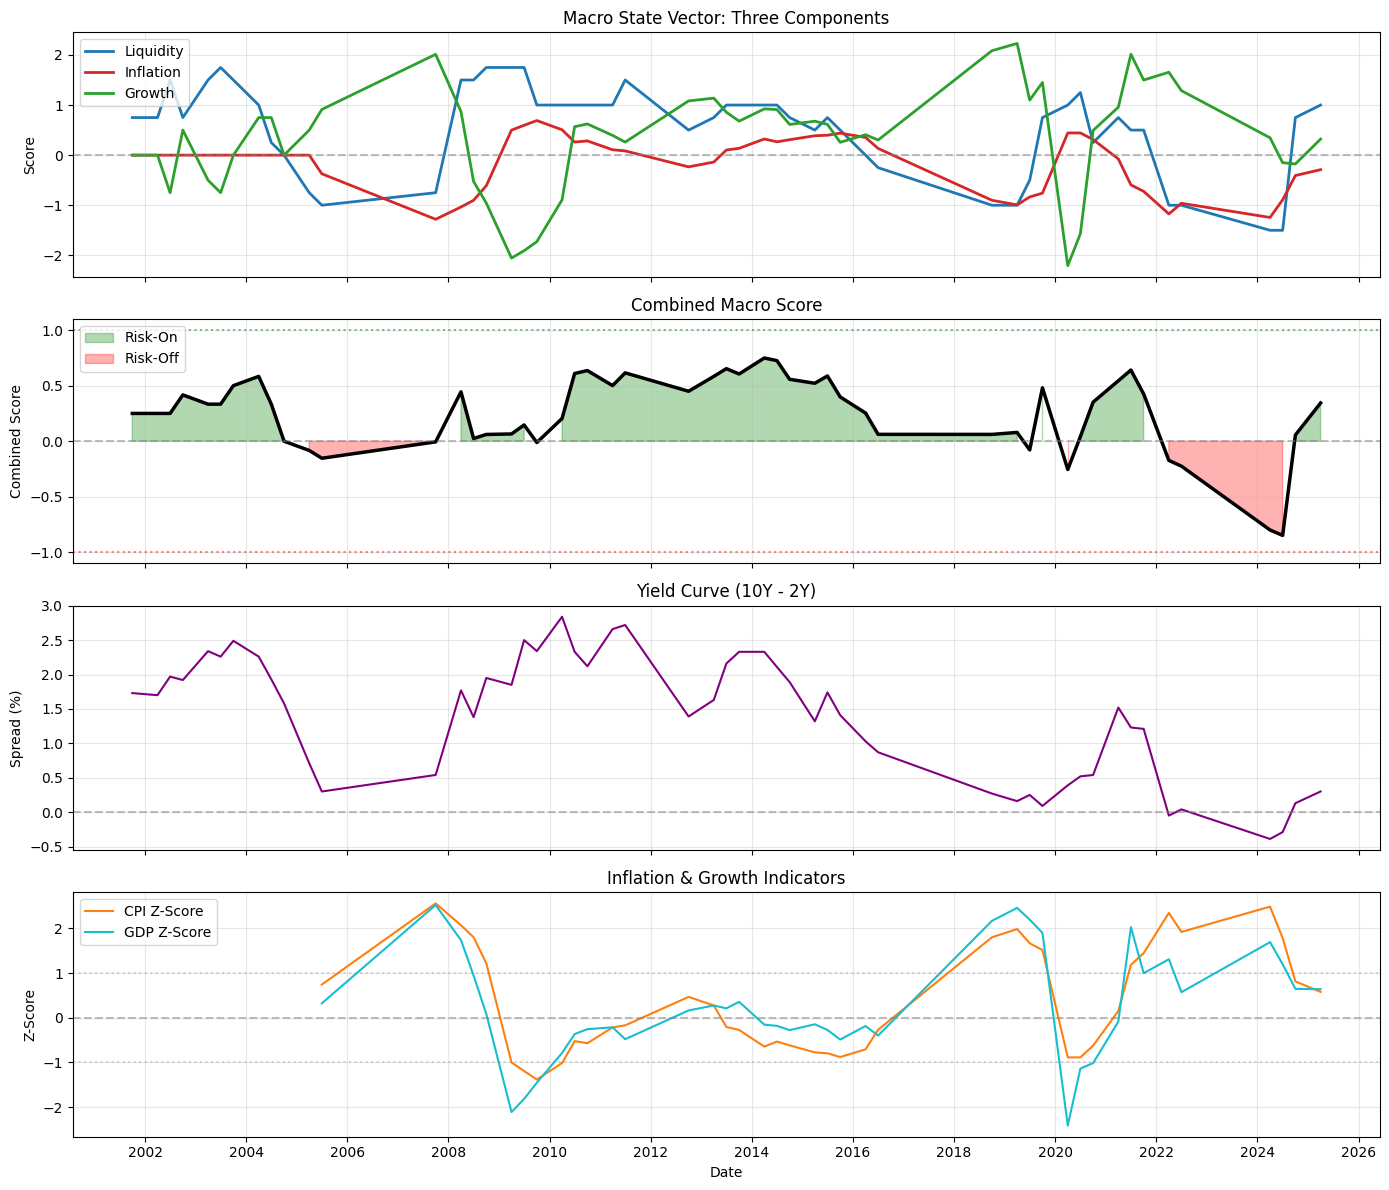


MACRO STATE VECTOR - LATEST READING

Date: 2025-04-01

COMPONENT                      SCORE            INTERPRETATION
----------------------------------------------------------------------
Liquidity Score                 1.00             Accommodative
Inflation Score                -0.29                  Elevated
Growth Score                    0.32                 Expanding
----------------------------------------------------------------------
MACRO SCORE                     0.34                   NEUTRAL

DETAILED INDICATORS

Yield Curve:        0.30%  (Score: 0.0)
Policy Rate Change: -1.00%  (Score: 2.0)
CPI YoY:            8.61%  (Z: 0.58, Score: -0.6)
GDP YoY:            15.76%  (Z: 0.64, Score: 0.6)
Unemployment Δ:     0.00%  (Score: 0.0)

HISTORICAL CONTEXT (Last 10 Periods)
      DATE  Liquidity_Score  Inflation_Score  Growth_Score  Macro_Score
2020-10-01             0.25         0.311070      0.493382     0.351484
2021-04-01             0.75        -0.075461      0.956900    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

investor_type = input("Enter your investment type (e.g., 'conservative', 'balanced', 'aggressive'): ").strip().lower()

# Load and prepare data
df = pd.read_csv("macro_data1.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values('DATE').reset_index(drop=True)

print(f"Loaded dataset: {df.shape[0]} rows from {df['DATE'].min()} to {df['DATE'].max()}")
print(f"Available columns: {list(df.columns)}")

# ============================================================================
# PASS 2: STRUCTURED MACRO SCORING
# Groups: Liquidity, Inflation, Growth
# Scale: -2 (very bearish) to +2 (very bullish)
# ============================================================================

# Configuration
periods = 4           # quarters for YoY
window = 20           # ~5 years rolling window
min_periods = 8       # minimum data points

# ============================================================================
# GROUP 1: LIQUIDITY
# ============================================================================

print("\n" + "="*70)
print("PROCESSING LIQUIDITY INDICATORS")
print("="*70)

# 1. Yield Curve (10Y - 2Y)
if 'Treasury10Y' in df.columns and 'Treasury2Y' in df.columns:
    df[['Treasury10Y', 'Treasury2Y']] = df[['Treasury10Y', 'Treasury2Y']].ffill()
    df['YieldCurve'] = df['Treasury10Y'] - df['Treasury2Y']
    
    def yield_curve_score(spread):
        """
        Smooth scoring for yield curve
        Steeper = more accommodative = positive for growth
        """
        if pd.isna(spread):
            return 0
        if spread <= -1.0:
            return -2
        elif spread <= -0.5:
            return -1.5
        elif spread < 0:
            return -1
        elif spread < 0.5:
            return 0
        elif spread < 1.0:
            return 0.5
        elif spread < 1.5:
            return 1
        elif spread < 2.0:
            return 1.5
        else:
            return 2
    
    df['Liquidity_YieldCurve'] = df['YieldCurve'].apply(yield_curve_score)
    print("✓ Yield Curve scored")
else:
    df['YieldCurve'] = df['Liquidity_YieldCurve'] = 0
    print("✗ Yield Curve data not found")

# 2. Policy Rate Change (if available)
if 'FedFunds' in df.columns:
    df['PolicyRate_Change'] = df['FedFunds'].diff(periods=2)  # 6-month change
    
    def policy_rate_score(change):
        """
        Falling rates = easing = positive
        Rising rates = tightening = negative
        """
        if pd.isna(change):
            return 0
        if change <= -1.0:
            return 2      # rapid easing
        elif change <= -0.5:
            return 1.5
        elif change < -0.1:
            return 1
        elif change < 0.1:
            return 0      # stable
        elif change < 0.5:
            return -1
        elif change < 1.0:
            return -1.5
        else:
            return -2     # rapid tightening
    
    df['Liquidity_PolicyRate'] = df['PolicyRate_Change'].apply(policy_rate_score)
    print("✓ Policy Rate scored")
else:
    df['PolicyRate_Change'] = df['Liquidity_PolicyRate'] = 0
    print("✗ Policy Rate data not found (FedFunds column missing)")

# ============================================================================
# GROUP 2: INFLATION
# ============================================================================

print("\n" + "="*70)
print("PROCESSING INFLATION INDICATORS")
print("="*70)

# 1. CPI (Z-score approach)
if 'CPI' in df.columns:
    df['CPI_YoY'] = df['CPI'].pct_change(periods) * 100
    df['CPI_YoY_mean'] = df['CPI_YoY'].rolling(window=window, min_periods=min_periods).mean()
    df['CPI_YoY_std'] = df['CPI_YoY'].rolling(window=window, min_periods=min_periods).std()
    df['CPI_z'] = (df['CPI_YoY'] - df['CPI_YoY_mean']) / df['CPI_YoY_std']
    
    def inflation_score(z):
        """
        High inflation = negative (central bank tightening risk)
        Low/falling inflation = positive (easing potential)
        """
        if pd.isna(z):
            return 0
        z = np.clip(z, -3, 3)  # cap extreme values
        return -z  # invert: high inflation = bad
    
    df['Inflation_CPI'] = df['CPI_z'].apply(inflation_score)
    print("✓ CPI scored")
else:
    df['CPI_YoY'] = df['CPI_z'] = df['Inflation_CPI'] = 0
    print("✗ CPI data not found")

# 2. PMI or Manufacturing Proxy (if available)
pmi_col = None
for col in ['PMI', 'NAPM', 'ISM_Manufacturing']:
    if col in df.columns:
        pmi_col = col
        break

if pmi_col:
    def pmi_score(pmi):
        """
        PMI momentum and absolute level
        >55 = strong expansion
        50-55 = moderate expansion
        45-50 = slowing/contraction risk
        <45 = contraction
        """
        if pd.isna(pmi):
            return 0
        if pmi >= 55:
            return 1.5
        elif pmi >= 52:
            return 1
        elif pmi >= 50:
            return 0.5
        elif pmi >= 48:
            return 0
        elif pmi >= 45:
            return -1
        else:
            return -1.5
    
    df['Inflation_PMI'] = df[pmi_col].apply(pmi_score)
    print(f"✓ PMI scored (using {pmi_col})")
else:
    df['Inflation_PMI'] = 0
    print("✗ PMI data not found - using neutral score")

# ============================================================================
# GROUP 3: GROWTH
# ============================================================================

print("\n" + "="*70)
print("PROCESSING GROWTH INDICATORS")
print("="*70)

# 1. GDP (Z-score approach)
if 'GDP' in df.columns:
    df['GDP_YoY'] = df['GDP'].pct_change(periods) * 100
    df['GDP_YoY_mean'] = df['GDP_YoY'].rolling(window=window, min_periods=min_periods).mean()
    df['GDP_YoY_std'] = df['GDP_YoY'].rolling(window=window, min_periods=min_periods).std()
    df['GDP_z'] = (df['GDP_YoY'] - df['GDP_YoY_mean']) / df['GDP_YoY_std']
    
    def growth_score(z):
        """
        Strong growth = positive
        Weak growth = negative
        """
        if pd.isna(z):
            return 0
        z = np.clip(z, -3, 3)
        return z  # high GDP growth = good
    
    df['Growth_GDP'] = df['GDP_z'].apply(growth_score)
    print("✓ GDP scored")
else:
    df['GDP_YoY'] = df['GDP_z'] = df['Growth_GDP'] = 0
    print("✗ GDP data not found")

# 2. Unemployment Change
unemp_col = None
for col in ['Unemployment', 'UnemploymentRate', 'UNRATE']:
    if col in df.columns:
        unemp_col = col
        break

if unemp_col:
    df['Unemployment_Change'] = df[unemp_col].diff(periods=2)  # 6-month change
    
    def unemployment_score(change):
        """
        Falling unemployment = positive
        Rising unemployment = negative (recession signal)
        """
        if pd.isna(change):
            return 0
        if change <= -1.0:
            return 2      # rapidly improving
        elif change <= -0.5:
            return 1.5
        elif change < -0.1:
            return 1
        elif change < 0.1:
            return 0
        elif change < 0.5:
            return -1
        elif change < 1.0:
            return -1.5
        else:
            return -2     # rapidly deteriorating
    
    df['Growth_Unemployment'] = df['Unemployment_Change'].apply(unemployment_score)
    print(f"✓ Unemployment scored (using {unemp_col})")
else:
    df['Unemployment_Change'] = df['Growth_Unemployment'] = 0
    print("✗ Unemployment data not found - using neutral score")

# ============================================================================
# AGGREGATE INTO MACRO STATE VECTOR
# ============================================================================

print("\n" + "="*70)
print("CALCULATING MACRO STATE VECTOR")
print("="*70)

# Calculate group averages (only from available indicators)
liquidity_cols = [c for c in ['Liquidity_YieldCurve', 'Liquidity_PolicyRate'] if c in df.columns]
inflation_cols = [c for c in ['Inflation_CPI', 'Inflation_PMI'] if c in df.columns]
growth_cols = [c for c in ['Growth_GDP', 'Growth_Unemployment'] if c in df.columns]

df['Liquidity_Score'] = df[liquidity_cols].mean(axis=1) if liquidity_cols else 0
df['Inflation_Score'] = df[inflation_cols].mean(axis=1) if inflation_cols else 0
df['Growth_Score'] = df[growth_cols].mean(axis=1) if growth_cols else 0

# Combined macro score (equal weights for now)
df['Macro_Score'] = df[['Liquidity_Score', 'Inflation_Score', 'Growth_Score']].mean(axis=1)

print(f"✓ Using {len(liquidity_cols)} liquidity indicators")
print(f"✓ Using {len(inflation_cols)} inflation indicators")
print(f"✓ Using {len(growth_cols)} growth indicators")

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)

# Plot 1: Macro State Vector Components
axes[0].plot(df['DATE'], df['Liquidity_Score'], label='Liquidity', linewidth=2, color='tab:blue')
axes[0].plot(df['DATE'], df['Inflation_Score'], label='Inflation', linewidth=2, color='tab:red')
axes[0].plot(df['DATE'], df['Growth_Score'], label='Growth', linewidth=2, color='tab:green')
axes[0].axhline(0, linestyle='--', color='gray', alpha=0.5)
axes[0].set_ylabel('Score')
axes[0].set_title('Macro State Vector: Three Components')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: Combined Macro Score
axes[1].plot(df['DATE'], df['Macro_Score'], linewidth=2.5, color='black')
axes[1].axhline(0, linestyle='--', color='gray', alpha=0.5)
axes[1].axhline(1, linestyle=':', color='green', alpha=0.5)
axes[1].axhline(-1, linestyle=':', color='red', alpha=0.5)
axes[1].fill_between(df['DATE'], 0, df['Macro_Score'], 
                     where=df['Macro_Score']>=0, alpha=0.3, color='green', label='Risk-On')
axes[1].fill_between(df['DATE'], 0, df['Macro_Score'], 
                     where=df['Macro_Score']<0, alpha=0.3, color='red', label='Risk-Off')
axes[1].set_ylabel('Combined Score')
axes[1].set_title('Combined Macro Score')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Plot 3: Yield Curve
if 'YieldCurve' in df.columns:
    axes[2].plot(df['DATE'], df['YieldCurve'], color='purple', linewidth=1.5)
    axes[2].axhline(0, linestyle='--', color='gray', alpha=0.5)
    axes[2].set_ylabel('Spread (%)')
    axes[2].set_title('Yield Curve (10Y - 2Y)')
    axes[2].grid(True, alpha=0.3)

# Plot 4: CPI and GDP Z-scores
if 'CPI_z' in df.columns and df['CPI_z'].notna().any():
    axes[3].plot(df['DATE'], df['CPI_z'], label='CPI Z-Score', color='tab:orange')
if 'GDP_z' in df.columns and df['GDP_z'].notna().any():
    axes[3].plot(df['DATE'], df['GDP_z'], label='GDP Z-Score', color='tab:cyan')
axes[3].axhline(0, linestyle='--', color='gray', alpha=0.5)
axes[3].axhline(1, linestyle=':', color='gray', alpha=0.3)
axes[3].axhline(-1, linestyle=':', color='gray', alpha=0.3)
axes[3].set_ylabel('Z-Score')
axes[3].set_title('Inflation & Growth Indicators')
axes[3].legend(loc='upper left')
axes[3].grid(True, alpha=0.3)

axes[3].xaxis.set_major_locator(mdates.YearLocator(2))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# ============================================================================
# REPORTING
# ============================================================================

print("\n" + "="*70)
print("MACRO STATE VECTOR - LATEST READING")
print("="*70)

latest = df.iloc[-1]

print(f"\nDate: {latest['DATE'].strftime('%Y-%m-%d')}")
print(f"\n{'COMPONENT':<25} {'SCORE':>10} {'INTERPRETATION':>25}")
print("-"*70)
print(f"{'Liquidity Score':<25} {latest['Liquidity_Score']:>10.2f} {('Accommodative' if latest['Liquidity_Score']>0 else 'Restrictive'):>25}")
print(f"{'Inflation Score':<25} {latest['Inflation_Score']:>10.2f} {('Benign' if latest['Inflation_Score']>0 else 'Elevated'):>25}")
print(f"{'Growth Score':<25} {latest['Growth_Score']:>10.2f} {('Expanding' if latest['Growth_Score']>0 else 'Slowing'):>25}")
print("-"*70)
print(f"{'MACRO SCORE':<25} {latest['Macro_Score']:>10.2f} {('RISK-ON' if latest['Macro_Score']>0.5 else 'RISK-OFF' if latest['Macro_Score']<-0.5 else 'NEUTRAL'):>25}")
print("="*70)

print("\n" + "="*70)
print("DETAILED INDICATORS")
print("="*70)
if 'YieldCurve' in df.columns:
    print(f"\nYield Curve:        {latest['YieldCurve']:.2f}%  (Score: {latest['Liquidity_YieldCurve']:.1f})")
if 'PolicyRate_Change' in df.columns and pd.notna(latest.get('PolicyRate_Change')):
    print(f"Policy Rate Change: {latest['PolicyRate_Change']:.2f}%  (Score: {latest['Liquidity_PolicyRate']:.1f})")
if 'CPI_YoY' in df.columns and pd.notna(latest.get('CPI_YoY')):
    print(f"CPI YoY:            {latest['CPI_YoY']:.2f}%  (Z: {latest['CPI_z']:.2f}, Score: {latest['Inflation_CPI']:.1f})")
if 'GDP_YoY' in df.columns and pd.notna(latest.get('GDP_YoY')):
    print(f"GDP YoY:            {latest['GDP_YoY']:.2f}%  (Z: {latest['GDP_z']:.2f}, Score: {latest['Growth_GDP']:.1f})")
if 'Unemployment_Change' in df.columns and pd.notna(latest.get('Unemployment_Change')):
    print(f"Unemployment Δ:     {latest['Unemployment_Change']:.2f}%  (Score: {latest['Growth_Unemployment']:.1f})")

print("\n" + "="*70)
print("HISTORICAL CONTEXT (Last 10 Periods)")
print("="*70)
print(df[['DATE', 'Liquidity_Score', 'Inflation_Score', 'Growth_Score', 'Macro_Score']].tail(10).to_string(index=False))

# Save enhanced dataset
df.to_csv("macro_data_scored.csv", index=False)
print("\n✓ Saved enhanced dataset to: macro_data_scored.csv")
print("\n" + "="*70)
print("PASS 2 COMPLETE!")
print("="*70)

